# N-RDD2024 Bangladesh Road Damage Detection
## YOLOv11m · 10 Classes · Severity Grading · Cost Estimation · GPS Heatmap

**Pipeline:** Detect → Grade Severity → Estimate BDT Cost → GPS Heatmap → Priority Dashboard

**Dataset:** N-RDD2024-BD (19,095 images · 10 defect classes · 6 countries)  
**Model:** YOLOv11m (medium) — fits 12-hour Kaggle limit  
**GPU:** Enable `Settings → Accelerator → GPU T4 x2`

| Code | Class | Bangladesh relevance |
|------|-------|---------------------|
| D00 | Longitudinal crack | Highway overloading, subsidence |
| D10 | Transverse crack | Temperature stress, poor base |
| D20 | Alligator crack | Full resurfacing needed |
| D30 | Repaired crack | Track repair quality post-monsoon |
| D40 | Pothole | Most common, accident risk |
| D50 | Pedestrian crossing blur | School zones, road safety |
| D60 | Lane line blur | Highway accidents |
| D70 | Manhole cover | Dhaka urban roads |
| D80 | Patchy road | Post-monsoon patchwork |
| D90 | Rutting | Heavy truck routes |

## Cell 1 — Install Dependencies

In [1]:
%%bash
pip install ultralytics folium pandas numpy matplotlib seaborn pillow opencv-python-headless tqdm pyyaml -q
echo "All dependencies installed."

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 88.5 MB/s eta 0:00:00
All dependencies installed.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## Cell 2 — Imports & Environment

In [2]:
import os, sys, json, random, warnings, math
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
import folium
from folium.plugins import HeatMap
import torch
from ultralytics import YOLO
import yaml
warnings.filterwarnings('ignore')
print(f'PyTorch   : {torch.__version__}')
print(f'CUDA      : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU       : {torch.cuda.get_device_name(0)}')
    print(f'VRAM      : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device    : {DEVICE}')
print('Ready.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch   : 2.10.0+cu128
CUDA      : True
GPU       : Tesla T4
VRAM      : 15.6 GB
Device    : cuda
Ready.


## Cell 3 — Dataset Paths & Verification

In [3]:
import subprocess
result = subprocess.run(['find', '/kaggle/input', '-name', 'data.yaml'], capture_output=True, text=True)
print('data.yaml locations:'); print(result.stdout)

DATASET_ROOT = Path('/kaggle/input/datasets/azmainhaq/n-rdd2024-bd')
if not DATASET_ROOT.exists():
    for candidate in Path('/kaggle/input').rglob('data.yaml'):
        DATASET_ROOT = candidate.parent; break

def find_split(root, cands):
    for c in cands:
        if (root/c/'images').exists(): return c
    return None

TRAIN_SPLIT = find_split(DATASET_ROOT, ['train','Train'])
VAL_SPLIT   = find_split(DATASET_ROOT, ['valid','val'])
TEST_SPLIT  = find_split(DATASET_ROOT, ['test','Test'])
if TEST_SPLIT is None: TEST_SPLIT = VAL_SPLIT

CLASS_NAMES = [
    'D00-Longitudinal crack', 'D10-Transverse crack', 'D20-Alligator crack',
    'D30-Repaired crack',     'D40-Pothole',          'D50-Pedestrian crossing blur',
    'D60-Lane line blur',     'D70-Manhole cover',    'D80-Patchy road',
    'D90-Rutting',
]
NC = len(CLASS_NAMES)

print(f'Dataset root : {DATASET_ROOT}')
print(f'Train: {TRAIN_SPLIT} | Val: {VAL_SPLIT} | Test: {TEST_SPLIT}')
for split in [TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT]:
    if split is None: continue
    imgs = list((DATASET_ROOT/split/'images').glob('*.jpg')) + list((DATASET_ROOT/split/'images').glob('*.png'))
    lbls = list((DATASET_ROOT/split/'labels').glob('*.txt')) if (DATASET_ROOT/split/'labels').exists() else []
    print(f'  {split:8s}: {len(imgs):,} images  {len(lbls):,} labels')

data.yaml locations:
/kaggle/input/datasets/azmainhaq/n-rdd2024-bd/data.yaml

Dataset root : /kaggle/input/datasets/azmainhaq/n-rdd2024-bd
Train: train | Val: valid | Test: test
  train   : 15,196 images  15,196 labels
  valid   : 1,899 images  1,899 labels
  test    : 1,900 images  1,900 labels


## Cell 4 — Create data.yaml with Absolute Paths

In [4]:
DATA_YAML = Path('/kaggle/working/data.yaml')
data_cfg = {
    'train': str(DATASET_ROOT / TRAIN_SPLIT / 'images'),
    'val'  : str(DATASET_ROOT / VAL_SPLIT   / 'images'),
    'test' : str(DATASET_ROOT / TEST_SPLIT  / 'images'),
    'nc'   : NC,
    'names': CLASS_NAMES,
}
with open(DATA_YAML, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False)
print('data.yaml written:')
print(open(DATA_YAML).read())
for key in ['train','val','test']:
    p = Path(data_cfg[key])
    print(f'  {key}: {"OK" if p.exists() else "MISSING!"} -> {p}')

data.yaml written:
names:
- D00-Longitudinal crack
- D10-Transverse crack
- D20-Alligator crack
- D30-Repaired crack
- D40-Pothole
- D50-Pedestrian crossing blur
- D60-Lane line blur
- D70-Manhole cover
- D80-Patchy road
- D90-Rutting
nc: 10
test: /kaggle/input/datasets/azmainhaq/n-rdd2024-bd/test/images
train: /kaggle/input/datasets/azmainhaq/n-rdd2024-bd/train/images
val: /kaggle/input/datasets/azmainhaq/n-rdd2024-bd/valid/images

  train: OK -> /kaggle/input/datasets/azmainhaq/n-rdd2024-bd/train/images
  val: OK -> /kaggle/input/datasets/azmainhaq/n-rdd2024-bd/valid/images
  test: OK -> /kaggle/input/datasets/azmainhaq/n-rdd2024-bd/test/images


## Cell 5 — Exploratory Data Analysis

Counting class distribution (sample: 5000 label files)...


Labels: 100%|██████████| 5000/5000 [00:17<00:00, 288.52it/s]


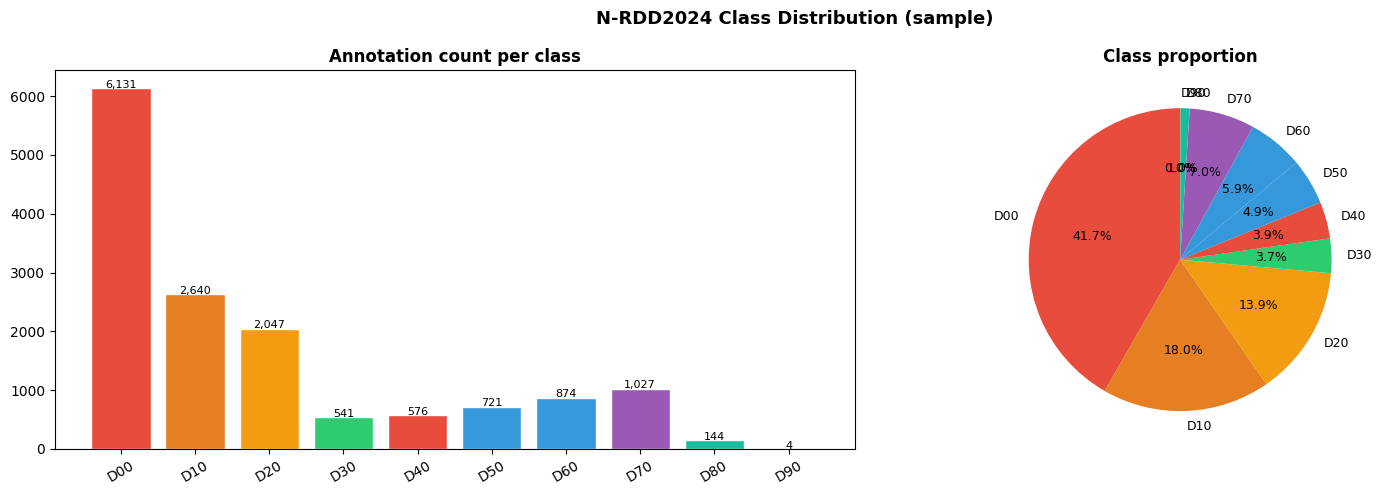


Class distribution:
     D00  D00-Longitudinal crack             6,131
     D10  D10-Transverse crack               2,640
     D20  D20-Alligator crack                2,047
     D30  D30-Repaired crack                   541
     D40  D40-Pothole                          576
     D50  D50-Pedestrian crossing blur         721
     D60  D60-Lane line blur                   874
     D70  D70-Manhole cover                  1,027
     D80  D80-Patchy road                      144
     D90  D90-Rutting                            4


In [5]:
print('Counting class distribution (sample: 5000 label files)...')
class_counts = defaultdict(int)
label_dir  = DATASET_ROOT / TRAIN_SPLIT / 'labels'
lbl_files  = list(label_dir.glob('*.txt'))[:5000]
for lbl_path in tqdm(lbl_files, desc='Labels'):
    try:
        for line in lbl_path.read_text().strip().split('\n'):
            p = line.strip().split()
            if p: class_counts[int(p[0])] += 1
    except: pass

cls_ids   = sorted(class_counts.keys())
cls_codes = [CLASS_NAMES[i].split('-')[0] for i in cls_ids]
counts    = [class_counts[i] for i in cls_ids]
colors    = ['#e74c3c','#e67e22','#f39c12','#2ecc71','#e74c3c',
             '#3498db','#3498db','#9b59b6','#1abc9c','#e67e22']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('N-RDD2024 Class Distribution (sample)', fontsize=13, fontweight='bold')
bars = axes[0].bar(cls_codes, counts, color=[colors[i] for i in cls_ids], edgecolor='white')
axes[0].set_title('Annotation count per class', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'{cnt:,}', ha='center', fontsize=8)
axes[1].pie(counts, labels=cls_codes, colors=[colors[i] for i in cls_ids],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':9})
axes[1].set_title('Class proportion', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nClass distribution:')
for i in cls_ids:
    print(f'  {CLASS_NAMES[i].split("-")[0]:>6}  {CLASS_NAMES[i]:30}  {class_counts[i]:>8,}')

## Cell 6 — Visualise Sample Images with Annotations

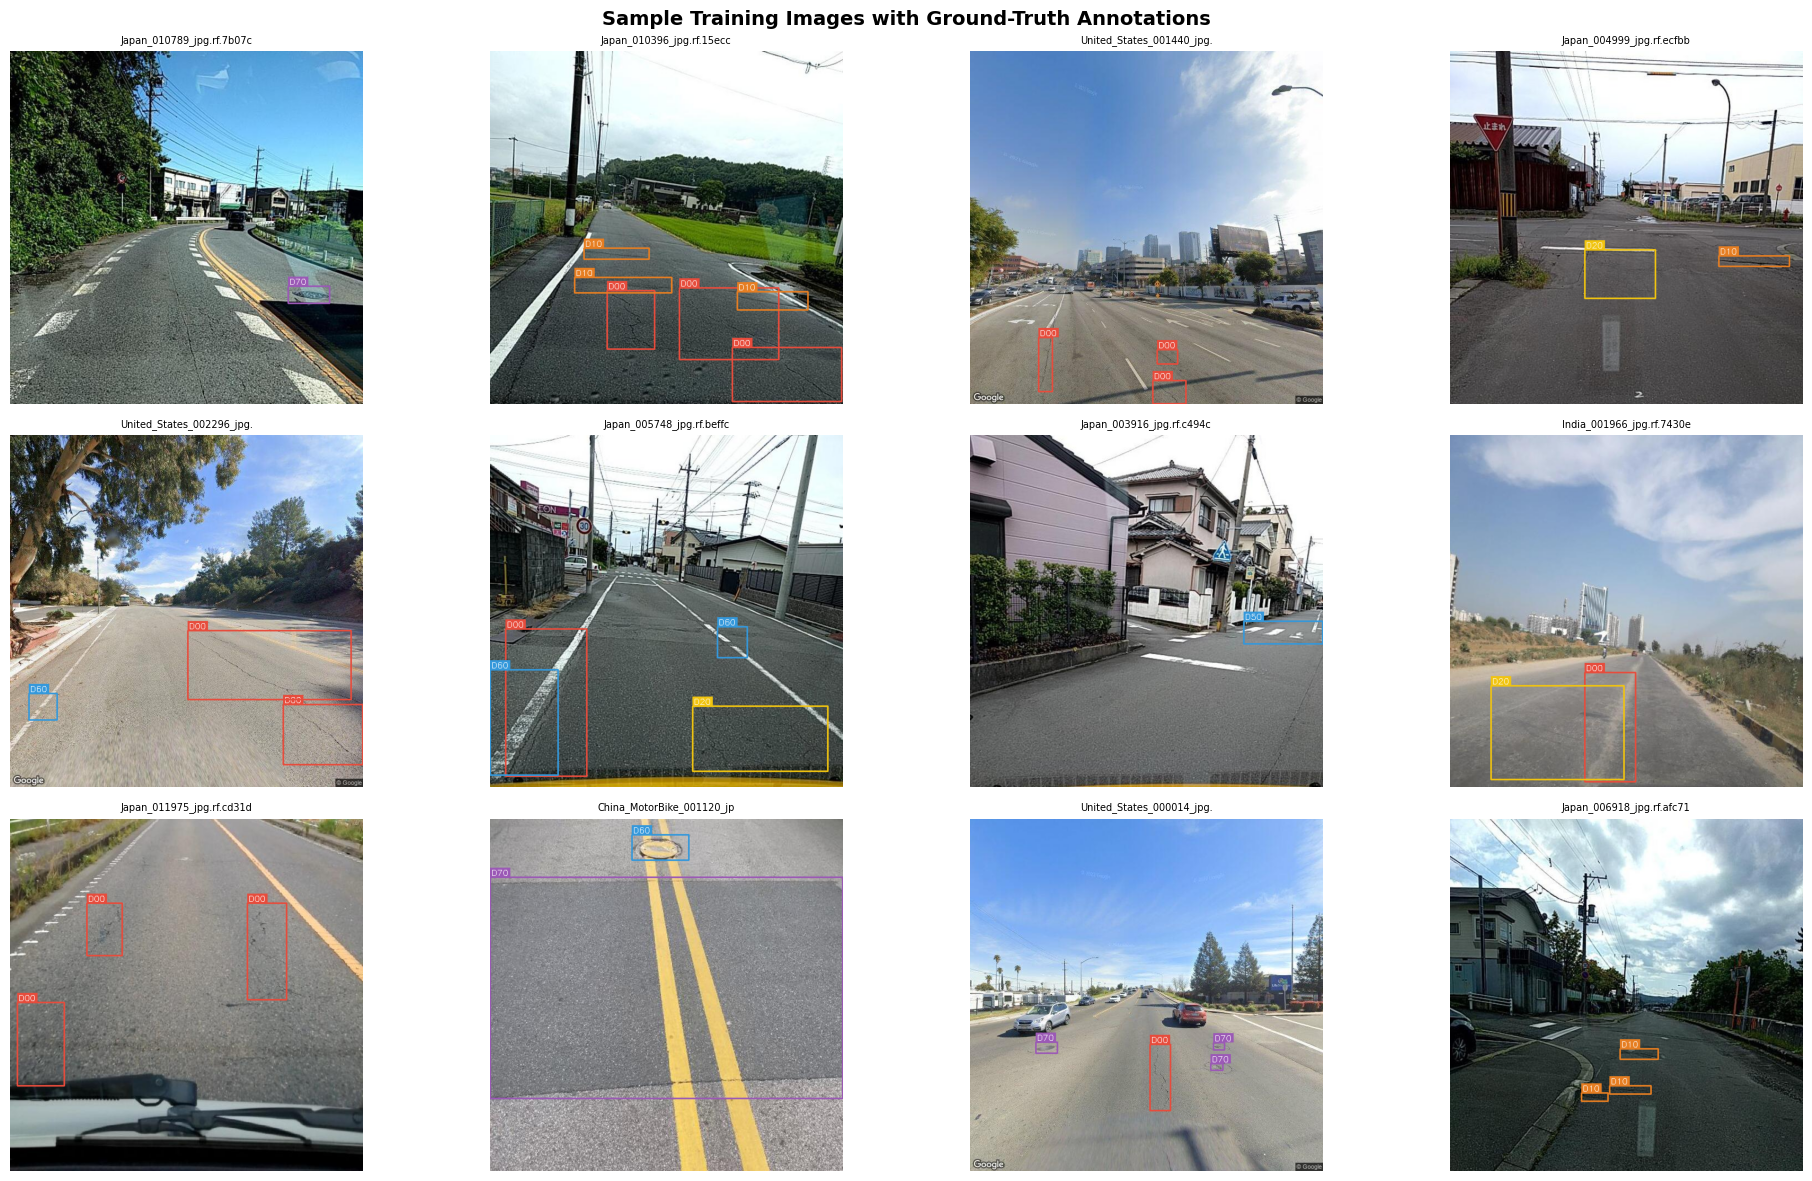

Saved -> /kaggle/working/sample_images.png


In [6]:
PALETTE = [(231,76,60),(230,126,34),(241,196,15),(46,204,113),(231,76,60),
           (52,152,219),(52,152,219),(155,89,182),(26,188,156),(230,126,34)]

def draw_boxes(img_path, lbl_path, class_names):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    if img is None: return None
    h, w = img.shape[:2]
    if Path(lbl_path).exists():
        for line in Path(lbl_path).read_text().strip().split('\n'):
            parts = line.strip().split()
            if len(parts) < 5: continue
            cid = int(parts[0])
            cx,cy,bw,bh = map(float, parts[1:5])
            x1=int((cx-bw/2)*w); y1=int((cy-bh/2)*h)
            x2=int((cx+bw/2)*w); y2=int((cy+bh/2)*h)
            col = PALETTE[cid % len(PALETTE)]
            cv2.rectangle(img,(x1,y1),(x2,y2),col,2)
            lbl = class_names[cid].split('-')[0] if cid < len(class_names) else str(cid)
            (tw,th),_ = cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,0.5,1)
            yb = max(y1-1,th+4)
            cv2.rectangle(img,(x1,yb-th-4),(x1+tw+4,yb),col,-1)
            cv2.putText(img,lbl,(x1+2,yb-2),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1)
    return img

img_dir  = DATASET_ROOT / TRAIN_SPLIT / 'images'
lbl_dir  = DATASET_ROOT / TRAIN_SPLIT / 'labels'
all_imgs = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
sample   = random.sample(all_imgs, min(12, len(all_imgs)))

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Sample Training Images with Ground-Truth Annotations',
             fontsize=14, fontweight='bold')
for ax, ip in zip(axes.flat, sample):
    vis = draw_boxes(ip, lbl_dir/(ip.stem+'.txt'), CLASS_NAMES)
    if vis is not None: ax.imshow(vis)
    ax.set_title(ip.name[:25], fontsize=7); ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> /kaggle/working/sample_images.png')

---
# STAGE 1 — YOLOv11m Detection Training

**Model:** YOLOv11m (medium) — faster than large, fits 12-hour Kaggle limit  
**50 epochs · cosine LR · AdamW · mosaic · cache=ram for speed**

In [7]:
import os

print('Starting with YOLOv11m — clean training, 50 epochs...')
model = YOLO('yolo11m.pt')
print(f'Parameters: {sum(p.numel() for p in model.model.parameters()):,}')

results = model.train(
    data             = str(DATA_YAML),
    imgsz            = 640,
    epochs           = 50,
    patience         = 10,
    batch            = 32,
    workers          = 8,
    cache            = 'ram',
    optimizer        = 'AdamW',
    lr0              = 0.001,
    lrf              = 0.01,
    momentum         = 0.937,
    weight_decay     = 0.0005,
    warmup_epochs    = 2,
    warmup_momentum  = 0.8,
    warmup_bias_lr   = 0.1,
    cos_lr           = True,
    box              = 7.5,
    cls              = 0.5,
    dfl              = 1.5,
    augment          = True,
    mosaic           = 1.0,
    mixup            = 0.05,
    copy_paste       = 0.0,
    degrees          = 3.0,
    translate        = 0.1,
    scale            = 0.5,
    flipud           = 0.1,
    fliplr           = 0.5,
    hsv_h            = 0.015,
    hsv_s            = 0.7,
    hsv_v            = 0.4,
    multi_scale      = False,
    device           = DEVICE,
    project          = '/kaggle/working/runs',
    name             = 'nrdd2024_yolo11m',
    exist_ok         = True,
    verbose          = True,
    seed             = SEED,
    amp              = True,
    plots            = True,
    save             = True,
    save_period      = 5,
)

WEIGHTS_BEST = '/kaggle/working/runs/nrdd2024_yolo11m/weights/best.pt'
WEIGHTS_LAST = '/kaggle/working/runs/nrdd2024_yolo11m/weights/last.pt'
print(f'Best weights -> {WEIGHTS_BEST}')

Starting with YOLOv11m — clean training, 50 epochs...
Parameters: 20,114,688
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=nrdd2024_yolo11m, nbs=64, nms=Fal

## Cell 8 — Evaluate on Test Set

In [8]:
best_model = YOLO(WEIGHTS_BEST)
val_results = best_model.val(
    data    = str(DATA_YAML),
    split   = 'test',
    imgsz   = 640,
    device  = DEVICE,
    verbose = True,
    conf    = 0.25,
    iou     = 0.50,
)
print('\n' + '='*55)
print(' DETECTION RESULTS — YOLOv11m')
print('='*55)
print(f'  mAP@50     : {val_results.box.map50:.4f}')
print(f'  mAP@50-95  : {val_results.box.map:.4f}')
print(f'  Precision  : {val_results.box.p.mean():.4f}')
print(f'  Recall     : {val_results.box.r.mean():.4f}')
f1 = 2*val_results.box.p.mean()*val_results.box.r.mean() / (val_results.box.p.mean()+val_results.box.r.mean()+1e-9)
print(f'  F1         : {f1:.4f}')
if hasattr(val_results.box, 'ap50'):
    print('\nPer-class AP@50:')
    print(f'  {"Code":>6}  {"Name":30}  {"AP@50":>8}')
    print('  ' + '-'*50)
    for i, ap in enumerate(val_results.box.ap50):
        name = CLASS_NAMES[i] if i < NC else f'cls{i}'
        print(f'  {name.split("-")[0]:>6}  {name:30}  {ap:.4f}')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,037,742 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11.7±5.6 MB/s, size: 75.8 KB)
val: Scanning /kaggle/input/datasets/azmainhaq/n-rdd2024-bd/test/labels... 1900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1900/1900 162.9it/s 11.7s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/azmainhaq/n-rdd2024-bd/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 35% ━━━━──────── 42/119 1.9it/s 22.1s<40.6sWARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 36% ━━━━──────── 43/119 1.3it/s 13:16<57.2s

## Cell 9 — Training Curves

In [ ]:
csv_path = Path('/kaggle/working/runs/nrdd2024_yolo11m/results.csv')
if not csv_path.exists():
    print('results.csv not found — check run name.')
else:
    df_tr = pd.read_csv(csv_path)
    df_tr.columns = df_tr.columns.str.strip()
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle('YOLOv11m Training Curves — N-RDD2024', fontsize=14, fontweight='bold')
    metrics = [
        ('train/box_loss', 'val/box_loss',      'Box Loss',      axes[0,0]),
        ('train/cls_loss', 'val/cls_loss',      'Class Loss',    axes[0,1]),
        ('train/dfl_loss', 'val/dfl_loss',      'DFL Loss',      axes[0,2]),
        ('metrics/precision(B)', None,          'Precision',     axes[0,3]),
        ('metrics/recall(B)',    None,          'Recall',        axes[1,0]),
        ('metrics/mAP50(B)',     None,          'mAP@50',        axes[1,1]),
        ('metrics/mAP50-95(B)', None,           'mAP@50-95',     axes[1,2]),
        ('lr/pg0',               None,          'Learning Rate', axes[1,3]),
    ]
    for tc, vc, title, ax in metrics:
        if tc in df_tr.columns:
            ax.plot(df_tr['epoch'], df_tr[tc], color='#3498db', linewidth=2, label='train')
        if vc and vc in df_tr.columns:
            ax.plot(df_tr['epoch'], df_tr[vc], color='#e74c3c', linewidth=2, linestyle='--', label='val')
        ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
        if vc and vc in df_tr.columns: ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> /kaggle/working/training_curves.png')

## Cell 10 — Per-Class Performance

In [ ]:
if hasattr(val_results.box, 'ap50'):
    ap50_vals = val_results.box.ap50
    n = min(len(ap50_vals), NC)
    full_names = [CLASS_NAMES[i] if i < NC else f'cls{i}' for i in range(n)]
    col_list   = ['#e74c3c','#e67e22','#f39c12','#2ecc71','#e74c3c',
                  '#3498db','#3498db','#9b59b6','#1abc9c','#e67e22']
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(full_names, ap50_vals[:n], color=col_list[:n], edgecolor='white')
    ax.set_xlabel('AP@50', fontweight='bold')
    ax.set_title('Per-class AP@50 — YOLOv11m on N-RDD2024', fontweight='bold')
    mean_ap = ap50_vals[:n].mean()
    ax.axvline(x=mean_ap, color='#2c3e50', linestyle='--', linewidth=1.5,
               label=f'Mean: {mean_ap:.3f}')
    ax.legend()
    for bar, val in zip(bars, ap50_vals[:n]):
        ax.text(val+0.005, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('/kaggle/working/per_class_ap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Run Cell 8 first.')

---
# STAGE 2 — Severity Grading

Each bbox graded Minor / Moderate / Severe using area (60%) + confidence (40%).
Thresholds calibrated per defect class.

In [ ]:
SEVERITY_THRESHOLDS = {
    # class_id: (area_minor_max, area_moderate_max, conf_minor_max, conf_moderate_max)
    0: (1500,  6000, 0.45, 0.70),  # D00 Longitudinal crack
    1: (1500,  6000, 0.45, 0.70),  # D10 Transverse crack
    2: (2000,  8000, 0.50, 0.75),  # D20 Alligator crack
    3: (3000, 10000, 0.40, 0.65),  # D30 Repaired crack
    4: (1200,  5000, 0.45, 0.70),  # D40 Pothole
    5: (5000, 15000, 0.40, 0.65),  # D50 Pedestrian crossing blur
    6: (5000, 15000, 0.40, 0.65),  # D60 Lane line blur
    7: (1000,  4000, 0.50, 0.75),  # D70 Manhole cover
    8: (2500,  9000, 0.45, 0.70),  # D80 Patchy road
    9: (3000, 10000, 0.50, 0.75),  # D90 Rutting
}
DEFAULT_THR = (2000, 8000, 0.45, 0.70)

def get_severity(bbox_area_px, confidence, class_id):
    t = SEVERITY_THRESHOLDS.get(class_id, DEFAULT_THR)
    a_min, a_mod, c_min, c_mod = t
    ag = 1 if bbox_area_px < a_min else 2 if bbox_area_px < a_mod else 3
    cg = 1 if confidence  < c_min  else 2 if confidence  < c_mod  else 3
    score = max(1, min(3, round(ag*0.6 + cg*0.4)))
    return {1:'minor', 2:'moderate', 3:'severe'}[score], score

print('Severity grading test:')
print(f'{"Class":>6}  {"Area":>8}  {"Conf":>6}  {"Severity":>10}  Score')
print('-'*45)
for cls_id, area, conf in [
    (0, 800,  0.40),(0, 4000,  0.65),(2, 500,   0.35),
    (2, 15000,0.90),(4, 1000,  0.45),(4, 8000,  0.88),
    (7, 500,  0.55),(7, 6000,  0.90)
]:
    sev, sc = get_severity(area, conf, cls_id)
    print(f'{CLASS_NAMES[cls_id].split("-")[0]:>6}  {area:>8,}  {conf:>6.2f}  {sev:>10}  {sc}')

---
# STAGE 3 — BDT Cost Estimation

Per-class repair rates (BDT/m²) based on LGED schedule of rates 2023-24.

In [ ]:
COST_RATES = {
    0: {'minor':  600, 'moderate': 1800, 'severe':  4500},  # D00 Longitudinal
    1: {'minor':  600, 'moderate': 1800, 'severe':  4500},  # D10 Transverse
    2: {'minor': 1500, 'moderate': 4000, 'severe':  9000},  # D20 Alligator
    3: {'minor':  400, 'moderate': 1000, 'severe':  2500},  # D30 Repaired
    4: {'minor': 1200, 'moderate': 3000, 'severe':  7000},  # D40 Pothole
    5: {'minor':  800, 'moderate': 2000, 'severe':  4000},  # D50 Cross. blur
    6: {'minor':  500, 'moderate': 1200, 'severe':  2800},  # D60 Lane blur
    7: {'minor': 2000, 'moderate': 5000, 'severe': 12000},  # D70 Manhole
    8: {'minor': 1000, 'moderate': 2500, 'severe':  6000},  # D80 Patchy
    9: {'minor': 1500, 'moderate': 4000, 'severe':  8500},  # D90 Rutting
}
PX_TO_METER = 7.0 / 640.0
PX2_TO_M2   = PX_TO_METER ** 2

def estimate_cost(w_px, h_px, class_id, severity):
    area_m2  = w_px * h_px * PX2_TO_M2
    rates    = COST_RATES.get(class_id, COST_RATES[4])
    cost_bdt = round(area_m2 * rates.get(severity, rates['moderate']), 2)
    return round(area_m2, 4), cost_bdt

print(f'{"ID":>3}  {"Class":30}  {"Minor":>8}  {"Moderate":>10}  {"Severe":>8}')
print('-'*65)
for cid, r in COST_RATES.items():
    print(f'{cid:>3}  {CLASS_NAMES[cid]:30}  {r["minor"]:>8,}  {r["moderate"]:>10,}  {r["severe"]:>8,}')

---
# STAGE 4 — Full Inference Pipeline

Single pass: detect all 10 defect classes, grade severity, estimate BDT cost.

In [ ]:
DHAKA_CENTER = (23.8103, 90.4125)
SEV_BGR = {'minor':(53,200,53), 'moderate':(30,160,220), 'severe':(40,40,220)}
SEV_HEX = {'minor':'green', 'moderate':'orange', 'severe':'red'}

def get_gps(img_path):
    try:
        from PIL.ExifTags import TAGS, GPSTAGS
        exif = Image.open(img_path)._getexif()
        if exif:
            for tid, val in exif.items():
                if TAGS.get(tid) == 'GPSInfo':
                    gps = {GPSTAGS.get(t,t):v for t,v in val.items()}
                    lat = gps['GPSLatitude']; lon = gps['GPSLongitude']
                    lat = lat[0]+lat[1]/60+lat[2]/3600
                    lon = lon[0]+lon[1]/60+lon[2]/3600
                    return round(float(lat),6), round(float(lon),6)
    except: pass
    return (round(DHAKA_CENTER[0]+np.random.uniform(-0.15,0.15),6),
            round(DHAKA_CENTER[1]+np.random.uniform(-0.15,0.15),6))

def run_pipeline(img_path, model, conf_thr=0.30):
    frame = cv2.imread(str(img_path))
    if frame is None: return [], None
    h, w  = frame.shape[:2]
    lat, lon = get_gps(img_path)
    result = model.predict(img_path, conf=conf_thr, iou=0.45,
                           verbose=False, device=DEVICE)[0]
    dets = []; vis = frame.copy()
    if result.boxes is not None and len(result.boxes) > 0:
        for box in result.boxes:
            x1,y1,x2,y2 = map(int, box.xyxy[0].cpu().numpy())
            conf   = float(box.conf[0].cpu())
            cls_id = int(box.cls[0].cpu())
            x1,y1 = max(0,x1),max(0,y1); x2,y2 = min(w,x2),min(h,y2)
            if (x2-x1)<8 or (y2-y1)<8: continue
            cls_name  = CLASS_NAMES[cls_id] if cls_id < NC else f'cls{cls_id}'
            bbox_area = (x2-x1)*(y2-y1)
            severity, sev_score = get_severity(bbox_area, conf, cls_id)
            area_m2, cost_bdt   = estimate_cost(x2-x1, y2-y1, cls_id, severity)
            col = SEV_BGR[severity]
            cv2.rectangle(vis,(x1,y1),(x2,y2),col,2)
            lbl = '{} {} {:.2f} BDT{:,.0f}'.format(
                cls_name.split('-')[0], severity.upper()[:3], conf, cost_bdt)
            (tw,th),_ = cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,0.45,1)
            yb = max(y1-1,th+5)
            cv2.rectangle(vis,(x1,yb-th-4),(x1+tw+4,yb),col,-1)
            cv2.putText(vis,lbl,(x1+2,yb-2),cv2.FONT_HERSHEY_SIMPLEX,0.45,(255,255,255),1)
            dets.append({
                'image':Path(img_path).name, 'lat':lat, 'lon':lon,
                'x1':x1,'y1':y1,'x2':x2,'y2':y2,
                'class_id':cls_id, 'class_name':cls_name,
                'conf':round(conf,4), 'severity':severity,
                'sev_score':sev_score, 'area_m2':area_m2, 'cost_bdt':cost_bdt
            })
    if dets:
        total = sum(d['cost_bdt'] for d in dets)
        for i, txt in enumerate([f'Detections: {len(dets)}',
                                  f'Total: BDT {total:,.0f}']):
            cv2.putText(vis,txt,(10,26+i*22),cv2.FONT_HERSHEY_SIMPLEX,0.65,(255,255,255),3)
            cv2.putText(vis,txt,(10,26+i*22),cv2.FONT_HERSHEY_SIMPLEX,0.65,(20,20,20),1)
    return dets, vis

print('Pipeline ready.')

## Cell 14 — Run Pipeline on Test Set

In [ ]:
det_model = YOLO(WEIGHTS_BEST)
test_img_dir = DATASET_ROOT / TEST_SPLIT / 'images'
test_images  = list(test_img_dir.glob('*.jpg')) + list(test_img_dir.glob('*.png'))
if not test_images: raise RuntimeError(f'No images in {test_img_dir}')
print(f'Running on {len(test_images):,} images from "{TEST_SPLIT}"...')

all_dets = []
for img_path in tqdm(test_images, desc='Inference'):
    dets, _ = run_pipeline(str(img_path), det_model)
    all_dets.extend(dets)

df = pd.DataFrame(all_dets)
print(f'\nTotal detections : {len(df):,}')
if len(df) > 0:
    print('\nSeverity breakdown:')
    for sev, cnt in df['severity'].value_counts().items():
        print(f'  {sev:10s}: {cnt:,} ({cnt*100/len(df):.1f}%)')
    print('\nTop 5 classes:')
    for cls, cnt in df['class_name'].value_counts().head(5).items():
        print(f'  {cls}: {cnt:,}')
    print(f'\nTotal repair cost  : BDT {df["cost_bdt"].sum():,.0f}')
    print(f'Avg cost/detection : BDT {df["cost_bdt"].mean():,.0f}')
df.to_csv('/kaggle/working/pipeline_results.csv', index=False)
print('\nSaved -> /kaggle/working/pipeline_results.csv')

## Cell 15 — Visualise Detection Results

In [ ]:
if test_images:
    n_show = min(9, len(test_images))
    sample_vis = random.sample(test_images, n_show)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('Pipeline Results  (green=minor  amber=moderate  red=severe)',
                 fontsize=13, fontweight='bold')
    for ax, ip in zip(axes.flat, sample_vis):
        dets, vis = run_pipeline(str(ip), det_model)
        if vis is not None:
            ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        n_s = sum(1 for d in dets if d['severity']=='severe')
        n_m = sum(1 for d in dets if d['severity']=='moderate')
        total = sum(d['cost_bdt'] for d in dets)
        ax.set_title(f'{len(dets)} det | S:{n_s} M:{n_m} | BDT {total:,.0f}',
                     fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('/kaggle/working/detection_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> /kaggle/working/detection_results.png')

## Cell 16 — Analysis Dashboard

In [ ]:
if len(df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle('Detection Analysis Dashboard — N-RDD2024 Bangladesh',
                 fontsize=14, fontweight='bold')
    scm = {'minor':'#2ecc71','moderate':'#f39c12','severe':'#e74c3c'}

    sev_c = df['severity'].value_counts()
    axes[0,0].bar(sev_c.index, sev_c.values,
                  color=[scm.get(s,'gray') for s in sev_c.index], edgecolor='white')
    axes[0,0].set_title('Severity Distribution', fontweight='bold')
    for i,(k,v) in enumerate(sev_c.items()):
        axes[0,0].text(i, v+1, str(v), ha='center', fontweight='bold')

    cls_c = df['class_name'].value_counts().head(10)
    short = [n.split('-')[0] for n in cls_c.index]
    axes[0,1].barh(short[::-1], cls_c.values[::-1], color='#3498db', edgecolor='white')
    axes[0,1].set_title('Detections per Class', fontweight='bold')

    cost_cls = df.groupby('class_name')['cost_bdt'].sum().sort_values(ascending=False)
    sc2 = [n.split('-')[0] for n in cost_cls.index]
    axes[0,2].barh(sc2[::-1], cost_cls.values[::-1]/1000, color='#9b59b6', edgecolor='white')
    axes[0,2].set_title('Total Cost by Class (BDT 000s)', fontweight='bold')

    axes[1,0].hist(df['cost_bdt'], bins=40, color='#e67e22', edgecolor='white')
    axes[1,0].set_title('Repair Cost Distribution', fontweight='bold')
    axes[1,0].set_xlabel('BDT per detection')

    for sev, color in scm.items():
        sub = df[df['severity']==sev]
        if len(sub) > 0:
            axes[1,1].scatter(sub['conf'], sub['area_m2'],
                              alpha=0.5, label=sev, color=color, s=20)
    axes[1,1].set_title('Confidence vs Area by Severity', fontweight='bold')
    axes[1,1].set_xlabel('Detection Confidence')
    axes[1,1].set_ylabel('Damage Area (m2)')
    axes[1,1].legend()

    avg_sev = df.groupby('severity')['cost_bdt'].mean()
    so = [s for s in ['minor','moderate','severe'] if s in avg_sev.index]
    axes[1,2].bar(so, [avg_sev[s] for s in so],
                  color=[scm[s] for s in so], edgecolor='white')
    axes[1,2].set_title('Avg Cost by Severity (BDT)', fontweight='bold')

    plt.tight_layout()
    plt.savefig('/kaggle/working/analysis_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> /kaggle/working/analysis_dashboard.png')

---
# STAGE 5A — GPS Heatmap

In [ ]:
if len(df) > 0:
    m = folium.Map(location=[23.8103, 90.4125], zoom_start=12, tiles='CartoDB positron')
    heat_data = [[r['lat'], r['lon'], r['sev_score']] for _, r in df.iterrows()]
    HeatMap(heat_data, radius=22, blur=16, max_zoom=14,
            gradient={0.2:'blue',0.4:'cyan',0.6:'yellow',0.8:'orange',1.0:'red'},
            name='Damage Heatmap').add_to(m)

    mg = folium.FeatureGroup(name='Individual Detections', show=False)
    for _, row in df.iterrows():
        sc = SEV_HEX.get(row['severity'], 'gray')
        popup = ('<div style="font-family:Arial;font-size:12px;width:220px">'
                 '<b>{}</b><br>Severity: <b style="color:{}">{}</b><br>'
                 'Conf: {:.3f} | Area: {:.4f} m2<br>'
                 'Cost: <b>BDT {:,.0f}</b></div>').format(
            row['class_name'], sc, row['severity'].upper(),
            row['conf'], row['area_m2'], row['cost_bdt'])
        folium.CircleMarker(
            location=[row['lat'],row['lon']], radius=5,
            color=sc, fill=True, fill_opacity=0.75,
            popup=folium.Popup(popup, max_width=240),
            tooltip='{} | {} | BDT {:,.0f}'.format(
                row['class_name'].split('-')[0], row['severity'], row['cost_bdt'])
        ).add_to(mg)
    mg.add_to(m)

    legend = ('<div style="position:fixed;bottom:30px;left:30px;z-index:1000;'
              'background:white;padding:14px;border-radius:8px;'
              'border:1px solid #ccc;font-family:Arial;font-size:12px">'
              '<b>Road Damage Severity</b><br>'
              '<span style="color:green">&#9679;</span> Minor<br>'
              '<span style="color:orange">&#9679;</span> Moderate<br>'
              '<span style="color:red">&#9679;</span> Severe</div>')
    m.get_root().html.add_child(folium.Element(legend))
    folium.LayerControl().add_to(m)
    m.save('/kaggle/working/road_damage_heatmap.html')
    print('GPS heatmap saved -> /kaggle/working/road_damage_heatmap.html')

---
# STAGE 5B — Priority Dashboard

In [ ]:
if len(df) > 0:
    df['segment'] = df.apply(
        lambda r: '{:.3f},{:.3f}'.format(r['lat'], r['lon']), axis=1)
    priority = df.groupby('segment').agg(
        total_detections = ('class_name', 'count'),
        severe_count     = ('severity',   lambda x: (x=='severe').sum()),
        moderate_count   = ('severity',   lambda x: (x=='moderate').sum()),
        minor_count      = ('severity',   lambda x: (x=='minor').sum()),
        total_cost_bdt   = ('cost_bdt',  'sum'),
        avg_confidence   = ('conf',      'mean'),
        classes_found    = ('class_name', lambda x: ', '.join(
                            sorted(set([n.split('-')[0] for n in x])))),
        lat              = ('lat',       'mean'),
        lon              = ('lon',       'mean'),
    ).reset_index()
    priority['priority_score'] = (
        priority['severe_count']   * 3 +
        priority['moderate_count'] * 2 +
        priority['minor_count']    * 1
    )
    priority = priority.sort_values(
        ['priority_score','total_cost_bdt'], ascending=[False,False]
    ).reset_index(drop=True)
    priority.index += 1; priority.index.name = 'Rank'

    print('='*65)
    print(' ROAD REPAIR PRIORITY DASHBOARD')
    print('='*65)
    print(f'  Segments : {len(priority):,}')
    print(f'  Total BDT: {priority["total_cost_bdt"].sum():,.0f}')
    cols = ['segment','total_detections','severe_count',
            'moderate_count','total_cost_bdt','classes_found']
    print(priority[cols].head(15).to_string())
    priority.to_csv('/kaggle/working/priority_dashboard.csv', index=True)

    top_n = priority.head(min(12, len(priority)))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Road Repair Priority — Top Segments',
                 fontsize=13, fontweight='bold')
    x = list(range(len(top_n)))
    axes[0].bar(x, top_n['severe_count'].values,
                label='Severe',   color='#e74c3c')
    axes[0].bar(x, top_n['moderate_count'].values,
                label='Moderate', color='#f39c12',
                bottom=top_n['severe_count'].values)
    axes[0].bar(x, top_n['minor_count'].values,
                label='Minor',    color='#2ecc71',
                bottom=(top_n['severe_count']+top_n['moderate_count']).values)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(['S{}'.format(i+1) for i in x], rotation=30)
    axes[0].set_ylabel('Detections'); axes[0].legend()
    axes[0].set_title('Severity per segment')
    seg_labels = ['Seg {}'.format(i+1) for i in range(len(top_n))]
    axes[1].barh(seg_labels[::-1],
                 top_n['total_cost_bdt'].values[::-1]/1000,
                 color='#8e44ad', edgecolor='white')
    axes[1].set_xlabel('Cost (BDT thousands)')
    axes[1].set_title('Repair cost by segment')
    for i, v in enumerate(top_n['total_cost_bdt'].values[::-1]/1000):
        if v > 0:
            axes[1].text(v+0.3, i, '{:.1f}k'.format(v), va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('/kaggle/working/priority_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> /kaggle/working/priority_chart.png')

---
# Final Summary Report

In [ ]:
print('='*65)
print(' N-RDD2024 BANGLADESH ROAD DAMAGE DETECTION — SUMMARY')
print(' Model: YOLOv11m')
print('='*65)
try:
    print(f'\n[Detection metrics]')
    print(f'  mAP@50     : {val_results.box.map50:.4f}')
    print(f'  mAP@50-95  : {val_results.box.map:.4f}')
    print(f'  Precision  : {val_results.box.p.mean():.4f}')
    print(f'  Recall     : {val_results.box.r.mean():.4f}')
except:
    print('  (run Cell 8 for metrics)')

print('\n[Dataset splits]')
for split in [TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT]:
    if split:
        n = len(list((DATASET_ROOT/split/'images').glob('*.jpg')))
        print(f'  {split:8s}: {n:,} images')

if len(df) > 0:
    print(f'\n[Test set results]')
    print(f'  Total detections : {len(df):,}')
    print(f'  Severe           : {(df["severity"]=="severe").sum():,}')
    print(f'  Moderate         : {(df["severity"]=="moderate").sum():,}')
    print(f'  Minor            : {(df["severity"]=="minor").sum():,}')
    print(f'  Total cost (BDT) : {df["cost_bdt"].sum():,.0f}')
    print('\n[Top 3 defects by count]')
    for cls, cnt in df['class_name'].value_counts().head(3).items():
        print(f'  {cls}: {cnt:,}')
    print('\n[Top 3 defects by cost]')
    for cls, cost in df.groupby('class_name')['cost_bdt'].sum().nlargest(3).items():
        print(f'  {cls}: BDT {cost:,.0f}')

print('\n[Output files]')
outputs = [
    ('/kaggle/working/runs/nrdd2024_yolo11m/weights/best.pt', 'Model weights'),
    ('/kaggle/working/pipeline_results.csv',  'All detections CSV'),
    ('/kaggle/working/priority_dashboard.csv','Priority ranking'),
    ('/kaggle/working/road_damage_heatmap.html','GPS heatmap'),
    ('/kaggle/working/analysis_dashboard.png','Analysis charts'),
    ('/kaggle/working/training_curves.png',   'Training curves'),
    ('/kaggle/working/per_class_ap.png',      'Per-class AP chart'),
    ('/kaggle/working/detection_results.png', 'Sample detections'),
    ('/kaggle/working/priority_chart.png',    'Priority chart'),
]
for path, desc in outputs:
    ok = Path(path).exists()
    print(f'  [{"OK" if ok else "--"}] {desc}')
print('\n' + '='*65)